In [1]:
import torch
from mpmath import mpf
from mpmath import mp
import mpmath
import simulation_2MQRM as t
import numpy as np
import qutip as qt
import scipy as sp
import math
import matplotlib.pyplot as plt
import matplotlib
import colorcet as cc

In [2]:
mp.dps = 200
print(mp)

Mpmath settings:
  mp.prec = 668               [default: 53]
  mp.dps = 200                [default: 15]
  mp.trap_complex = False     [default: False]


In [3]:
def generate_detunings(delta_g,delta_e,wa,Dg,De,Cmat):
    M = int(np.min([Dg,De]))
    N = int(np.max([Dg,De]))
    Delta_g = [sum([delta_g[k]*np.abs(Cmat.U[k,j])**2 for k in range(Dg)]) for j in range(M)]
    Delta_e = [sum([delta_e[k]*np.abs(Cmat.Vt[k,j])**2 for k in range(De)]) for j in range(M)]
    Dmin = [Delta_e[i]-Delta_g[i] for i in range(M)]
    Dplu = [Delta_e[i]+Delta_g[i] for i in range(M)]
    if Dg>De:
        Dk = [delta_g[i] for i in range(M,N)]
    elif De>Dg:
        Dk = [delta_e[i] for i in range(M,N)]
    else:
        Dk = 0
    return Dmin, Dplu, Dk

In [4]:
def diagonalised_energies(trunc, wc, wa, Dg, De, Cmatobj, geff_list, delta_g, delta_e):
    systems_temp_list = [t.DoubleMultilevel(trunc, Dg, De, Cmatobj, g, delta_g, delta_e, wc, wa) for g in geff_list]
    systems_temp_list_energies = np.empty([geff_list_num], dtype = object)
    for k in range(geff_list_num):
        systems_temp_list[k].hamiltonian()
        systems_temp_list_energies[k] = np.array(systems_temp_list[k].H.eigenenergies())
    energy_temp_list1 = np.empty([len(systems_temp_list_energies[0])],dtype=object) #energy levels specifically!!
    additionscaling = [Cmatobj.svdvals[0]**2*g**2 + wa/2 for g in geff_list]
    for n in range(len(energy_temp_list1)): #the length is the same as N*D because hamiltonian diagonalisation is the amount of energy levels
        energy_temp_list1[n] = [systems_temp_list_energies[k][n] + additionscaling[k] for k in range(len(geff_list))]
    return energy_temp_list1

In [5]:
def generate_qfi_list_theor3_fast(wc, wa, Xq, Tlist, Dg, De,
                                  Dmin=0, Dplu=0, Dk=0,
                                  gprefactor=1, Ocutoff=0):
    # --- Laguerre polynomials (same as before, but reused) ---
    max_n = math.floor(Ocutoff + gprefactor**2 + 100)
    laguerrelist = [sp.special.laguerre(n, False) for n in range(max_n)]

    # --- basic dims / sign ---
    M = int(np.min([Dg, De]))
    N = int(np.max([Dg, De]))

    if Dg > De:
        p = mpf(-1)
    elif De > Dg:
        p = mpf(1)
    else:
        p = mpf(0)

    # --- parameters as mpf lists ---
    if Dmin == 0:
        Dmin = [mpf(0) for _ in range(M)]
    else:
        Dmin = [mpf(k) for k in Dmin]

    if Dplu == 0:
        Dplu = [mpf(0) for _ in range(M)]
    else:
        Dplu = [mpf(k) for k in Dplu]

    if Dk == 0:
        Dk = [mpf(0) for _ in range(N - M)]
    else:
        Dk = [mpf(k) for k in Dk]

    X = [mpf(k) for k in Xq]
    g = mpf(gprefactor)
    wf = mpf(wc)
    wa = mpf(wa)
    T = [mpf(k) for k in Tlist]
    num = len(Tlist)
    QFI = np.empty(num, dtype=float)

    # --- indices / cutoffs ---
    Ocutoff_int = int(Ocutoff)

    # depends only on X, wc, wa, gprefactor, Ocutoff; NOT on T
    Oindicatorbrightlist = [
        int(mp.floor(mpf(Ocutoff_int) + wa/2 + (gprefactor**2) * X[q] + 1))
        for q in range(M)
    ]
    maxO = max(Oindicatorbrightlist) + 1

    # --- dark-state energy levels: independent of T ---
    gamD = [-(mpf(h)*wf + wa*p*mpf(0.5)) for h in range(Ocutoff_int)]

    # --- bright-state gammas: independent of T ---
    gamB = [[mpf(0)] * maxO for _ in range(M)]
    GamB = [[mpf(0)] * maxO for _ in range(M)]

    for q in range(M):
        # SciPy Laguerre works in float, so we evaluate once per (q,h) and then promote to mpf
        x_arg = float(4 * g * g * X[q] / (wf * wf))
        pref = mpf(0.5) * (wa + Dmin[q]) * mp.exp(-2 * g * g * X[q] / (wf * wf))
        g_const = g * g * X[q] / wf - Dplu[q] * mpf(0.5)

        for h in range(Oindicatorbrightlist[q] + 1):
            gamB[q][h] = g_const - wf * mpf(h)
            GamB[q][h] = pref * mpf(laguerrelist[h](x_arg))

    NminusM = mpf(N - M)
    two = mpf(2)

    # --- loop over temperatures ---
    for t, Tt in enumerate(T):
        beta = 1 / Tt

        # dark: exp(beta * gamD)
        exgamD = [mp.exp(beta * gd) for gd in gamD]

        # bright: exp / cosh / tanh for beta*GamB, beta*gamB
        exgamB = [[mpf(0)] * maxO for _ in range(M)]
        coshGamB = [[mpf(0)] * maxO for _ in range(M)]
        tanhGamB = [[mpf(0)] * maxO for _ in range(M)]

        for q in range(M):
            for h in range(Oindicatorbrightlist[q] + 1):
                b = beta * gamB[q][h]
                G = beta * GamB[q][h]
                e = mp.exp(b)
                c = mp.cosh(G)
                exgamB[q][h] = e
                coshGamB[q][h] = c
                tanhGamB[q][h] = mp.tanh(G)

        # -------- Z --------
        Z_dark = NminusM * mp.fsum(exgamD)
        Z_bright = two * mp.fsum(
            mp.fsum(exgamB[q][h] * coshGamB[q][h]
                    for h in range(Oindicatorbrightlist[q]))
            for q in range(M)
        )
        Z = Z_dark + Z_bright

        # -------- S1 --------
        S1 = two * mp.fsum(
            mp.fsum(
                exgamB[q][h] * GamB[q][h] * GamB[q][h] / coshGamB[q][h]
                for h in range(Oindicatorbrightlist[q])
            )
            for q in range(M)
        )

        # -------- S2 --------
        S2_dark = NminusM * mp.fsum(
            gamD[h] * gamD[h] * exgamD[h] for h in range(Ocutoff_int)
        )

        S2_bright_terms = []
        for q in range(M):
            for h in range(Oindicatorbrightlist[q]):
                tmp = gamB[q][h] + GamB[q][h] * tanhGamB[q][h]
                S2_bright_terms.append(
                    exgamB[q][h] * coshGamB[q][h] * (tmp * tmp)
                )
        S2_bright = two * mp.fsum(S2_bright_terms)
        S2 = S2_dark + S2_bright

        # -------- S3 --------
        S3_dark = NminusM * mp.fsum(
            gamD[h] * exgamD[h] for h in range(Ocutoff_int)
        )
        S3_bright_terms = []
        for q in range(M):
            for h in range(Oindicatorbrightlist[q]):
                tmp = gamB[q][h] + GamB[q][h] * tanhGamB[q][h]
                S3_bright_terms.append(
                    exgamB[q][h] * coshGamB[q][h] * tmp
                )
        S3_bright = two * mp.fsum(S3_bright_terms)
        S3 = S3_dark + S3_bright

        QFI1 = S1 / Z
        QFI2 = S2 / Z
        QFI3 = -(S3 * S3) / (Z * Z)

        # still only convert to float at the very end
        QFI[t] = float((QFI1 + QFI2 + QFI3) / (Tt * Tt * Tt * Tt))

    return QFI

In [6]:
def AA_eigenvals(wc, wa, Xq, trunc, Dg, De, Dmin, Dplu, Dk, geff=1, splitenergies=False):
    M = np.min([Dg,De])
    N = np.max([Dg,De])
    X = Xq
    evalsB, evalsD = [], []
    for t in range(trunc):
        lag = sp.special.laguerre(t,False)
        for q in range(M):
            Em = wc*(t-geff**2*X[q]/wc**2) + 0.5*(Dplu[q])\
                            -0.5*(wa+Dmin[q])*np.exp(-2*X[q]*geff**2/wc**2)\
                                            *np.real(lag(4*X[q]*geff**2/wc**2))
            Ep = wc*(t-geff**2*X[q]/wc**2) + 0.5*(Dplu[q])\
                            +0.5*(wa+Dmin[q])*np.exp(-2*X[q]*geff**2/wc**2)\
                                            *np.real(lag(4*X[q]*geff**2/wc**2))
            evalsB.append(Em)
            evalsB.append(Ep)
        for k in range(N-M):
            if Dg>De:
                pm = -1
            elif Dg<De:
                pm = 1
            else:
                print('error? why are we doing this loop...')
            E = t*wc + pm*wa/2 + Dk[k]
            evalsD.append(E)
    if splitenergies==True:
        return evalsB, evalsD
    elif splitenergies==False:
        return [x for x in np.sort(evalsB+evalsD)]

def AA_energies_uptodark(wc,wa,Xq,O,Dg,De,Dmin,Dplu,Dk,geff=1, ordered = False):
    M = np.min([Dg,De])
    N = np.max([Dg,De])
    X = Xq
    laglist = [sp.special.laguerre(t,False) for t in range(math.floor(O+geff**2))]
   
    evalsD = []
    for n in range(O):
        for k in range(N-M):
            if Dg>De:
                pm = -1
            elif Dg<De:
                pm = 1
            else:
                print('error? why are we doing this loop...')
            E = n*wc + pm*wa/2 + Dk[k]
            evalsD.append(E)

    evalsB = []
    for q in range(len(X)):
        print(q)
        indicator = math.floor(O + wa/2 + geff**2 *X[q]) 
        print(indicator)
        for t in range(indicator):
            Em = wc*(t-geff**2*X[q]/wc**2) + 0.5*(Dplu[q])\
                            -0.5*(wa+Dmin[q])*np.exp(-2*X[q]*geff**2/wc**2)\
                                            *np.real(laglist[t](4*X[q]*geff**2/wc**2))
            Ep = wc*(t-geff**2*X[q]/wc**2) + 0.5*(Dplu[q])\
                            +0.5*(wa+Dmin[q])*np.exp(-2*X[q]*geff**2/wc**2)\
                                            *np.real(laglist[t](4*X[q]*geff**2/wc**2))
            evalsB.append(Em)
            evalsB.append(Ep)
    
    if ordered==True:
        ls = np.array([x for x in np.sort(evalsB+evalsD)])
        return ls[~np.isnan(ls)]
    else:
        evals = np.array(evalsB+evalsD)
        return evals[~np.isnan(evals)]

In [7]:
def logsumexp_mp(xs):
    # xs: list of mp.mpf
    m = max(xs)
    return m + mp.log(mp.fsum(mp.e**(x - m) for x in xs))

def generate_qfi_list_fromE(Elist, minT, maxT, num):
    E=[mp.mpf(e) for e in Elist]
    Tlist = [mpf(T) for T in np.geomspace(minT,maxT,num)]
    qfi_list = []
    Z_list_brute = []
    for T in Tlist:
        logweights  = [-(e/T) for e in E] 
        logZ  = logsumexp_mp(logweights)
        p = [mp.e**(logw-logZ) for logw in logweights]
        
        mu1 = mp.fsum(pi * ei for pi, ei in zip(p, E))
        mu2 = mp.fsum(pi * (ei * ei) for pi, ei in zip(p, E))
        var = mu2 - mu1 * mu1

        Z_list_brute.append(mp.e**logZ)
        qfi_list.append(var/(T**mpf(4)))
    return qfi_list, Tlist

#small g#
def generate_qfi_list_theor2(wc, wa, Xq, Tlist, Dg, De, Dmin=0, Dplu=0, Dk=0, gprefactor=1):
    M = int(np.min([Dg,De]))
    N = int(np.max([Dg,De]))
    if Dg>De:
        p=mpf(-1)
    elif De>Dg:
        p=mpf(1)
    else:
        p=mpf(0)
        
    if Dmin==0:
        Dmin = [mpf(0) for k in range(M)]
    else:
        Dmin = [mpf(k) for k in Dmin]
        
    if Dplu==0:
        Dplu = [mpf(0) for k in range(M)]
    else:
        Dplu = [mpf(k) for k in Dplu]
        
    if Dk==0:
        Dk = [mpf(0) for k in range(N-M)]
    else:
        Dk = [mpf(k) for k in Dk]
    
    X = [mpf(k) for k in Xq]
    g = mpf(gprefactor) #mpf(Xq[0])
    wf = mpf(wc)
    wa = mpf(wa)
    T = [mpf(k) for k in Tlist]
    num=len(Tlist)
    QFIlist1 = np.empty([num],dtype=object)
    QFIlist2 = np.empty([num],dtype=object)
    QFIlist3 = np.empty([num],dtype=object)
    QFI = np.empty([num],dtype=object)
    for t in range(len(T)):
        # per-q lists in mpf
        e1 = []
        e2 = []
        e3 = []
        ch = []
        sc = []
        th = []
        arg = []
        beta = 1/T[t]
        nmexp = []
        temp = []
        thing=[]
        for k in range(N-M):
            thing_k = (p*wa/mpf(2)+Dk[k])
            nmexp_k = mpmath.exp(-beta*thing_k)
            thing.append(thing_k); nmexp.append(nmexp_k)
        for q in range(M):
            e1_q = mpmath.exp((g*g)*X[q] * beta / wf)              # exp1
            e2_q = mpmath.exp(-1*mpf(2)*(g*g)*X[q] / (wf*wf))             # exp2
            e3_q = mpmath.exp(-beta/mpf(2) * Dplu[q])
            arg_q  = ((wa +Dmin[q])* beta / mpf(2)) * e2_q
            ch_q = mpmath.cosh(arg_q)
            th_q = mpmath.tanh(arg_q)
            e1.append(e1_q); e2.append(e2_q); ch.append(ch_q); th.append(th_q); sc.append(1/ch_q); e3.append(e3_q)
        Z = sum(nmexp[k] for k in range(N-M)) + mpf(2)*sum(e1[q]*e3[q]*ch[q] for q in range(M))
        S1 = mpf(1/2) * ( sum(((wa+Dmin[q])**mpf(2)) * e1[q] * (e2[q]**mpf(2)) * e3[q] * sc[q] for q in range(M)) ) 
        S2 =   sum(thing[k]*thing[k] * nmexp[k] for k in range(N-M))  + mpf(2) * sum( e1[q]*e3[q]*ch[q] * mpmath.power((g*g)*X[q]/wf - mpf(0.5)*Dplu[q] + mpf(0.5)*(wa+Dmin[q])*e2[q]*th[q], 2)  for q in range(M) )
        S3 =  -mpf(1) * sum(thing[k] * nmexp[k] for k in range(N-M))  + mpf(2)*sum( e1[q]*e3[q]*ch[q] * ( (g*g)*X[q]/wf - mpf(0.5)*Dplu[q] + mpf(0.5)*(wa+Dmin[q])*e2[q]*th[q] )  for q in range(M) ) 
        QFIlist1[t] = S1/Z
        QFIlist2[t] = S2/Z
        QFIlist3[t] = -(S3*S3)/(Z*Z)
        QFI[t] = float( (QFIlist1[t] + QFIlist2[t] + QFIlist3[t])/(mpmath.power(T[t],4)) )
    return QFI
    
#all g#
def generate_qfi_list_theor3(wc, wa, Xq, Tlist, Dg, De, Dmin=0, Dplu=0, Dk=0, gprefactor=1, Ocutoff = 0):
    laguerrelist = [sp.special.laguerre(n,False) for n in range(math.floor(Ocutoff+gprefactor**2+2))]
    M = int(np.min([Dg,De]))
    N = int(np.max([Dg,De]))
    if Dg>De:
        p=mpf(-1)
    elif De>Dg:
        p=mpf(1)
    else:
        p=mpf(0)
        
    if Dmin==0:
        Dmin = [mpf(0) for k in range(M)]
    else:
        Dmin = [mpf(k) for k in Dmin]
        
    if Dplu==0:
        Dplu = [mpf(0) for k in range(M)]
    else:
        Dplu = [mpf(k) for k in Dplu]
        
    if Dk==0:
        Dk = [mpf(0) for k in range(N-M)]
    else:
        Dk = [mpf(k) for k in Dk]
    
    X = [mpf(k) for k in Xq]
    g = mpf(gprefactor) #mpf(Xq[0])
    wf = mpf(wc)
    wa = mpf(wa)
    T = [mpf(k) for k in Tlist]
    num=len(Tlist)
    QFI = np.empty([num],dtype=object)
    
    for t in range(len(T)):
        Oindicatorbrightlist = [math.floor(Ocutoff + wa/2 + gprefactor**2 *X[q]+1) for q in range(M)]
        indicatordark =  Ocutoff
        beta = 1/T[t]
        
        gamD = [] #indep of q
        exgamD = [] #indep of q
        
        gamB = np.empty([M,max(Oindicatorbrightlist)+1],dtype=object)  #q,n both hmm
        GamB = np.empty([M,max(Oindicatorbrightlist)+1],dtype=object)
        exgamB = np.empty([M,max(Oindicatorbrightlist)+1],dtype=object)
        
        CoshGamB = np.empty([M,max(Oindicatorbrightlist)+1],dtype=object)
        TanhGamB = np.empty([M,max(Oindicatorbrightlist)+1],dtype=object)
        #darkstates
        for h in range(indicatordark):
            gamD_h = mpf(-1)*(mpf(h)*wf + wa*p*mpf(0.5))
            exgamD_h = mpmath.exp(beta*gamD_h)
            gamD.append(gamD_h); exgamD.append(exgamD_h)
        #brightbits
        for q in range(M):
            for h in range(Oindicatorbrightlist[q]+1):
                gamB[q,h] = g*g*X[q]/wf - Dplu[q]*mpf(0.5) - wf*mpf(h)
                GamB[q,h] = mpf(0.5)*(wa+Dmin[q])*mpmath.exp(mpf(-2)*g*g*X[q]/(wf*wf))*mpf(laguerrelist[h](float(4*g*g*X[q]/(wf*wf))))
                exgamB[q,h] = mpmath.exp(beta*gamB[q,h])
                CoshGamB[q,h] = mpmath.cosh(beta*GamB[q,h])
                TanhGamB[q,h] = mpmath.tanh(beta*GamB[q,h])
        Z = mpf(N-M)*sum(exgamD[h] for h in range(Ocutoff)) + mpf(2)*sum(sum(exgamB[k,h]*CoshGamB[k,h] for h in range(Oindicatorbrightlist[k])) for k in range(M))
        S1 = mpf(2)*sum(sum(exgamB[k,h] * GamB[k,h] * GamB[k,h] / CoshGamB[k,h] for h in range(Oindicatorbrightlist[k])) for k in range(M))
        S2 = mpf(N-M)*sum(gamD[h]*gamD[h]*exgamD[h] for h in range(Ocutoff)) + mpf(2)*sum(sum(exgamB[k,h]*CoshGamB[k,h]*mpmath.power(gamB[k,h]+GamB[k,h]*TanhGamB[k,h],2) for h in range(Oindicatorbrightlist[k])) for k in range(M))
        S3 = mpf(N-M)*sum(gamD[h]*exgamD[h] for h in range(Ocutoff)) + mpf(2)*sum(sum(exgamB[k,h]*CoshGamB[k,h]*(gamB[k,h]+GamB[k,h]*TanhGamB[k,h]) for h in range(Oindicatorbrightlist[k])) for k in range(M))
        QFI1 = S1/Z
        QFI2 = S2/Z
        QFI3 = -(S3*S3)/(Z*Z)
        QFI[t] = float( (QFI1 + QFI2 + QFI3)/(mpmath.power(T[t],4)) )
    return QFI

In [22]:
Dg=2
De=4
M = np.min([Dg,De])
N = np.max([Dg,De])
wf=1
wa=0.2

ep=0.1*wa
delta_g=np.array([-ep,ep])
delta_e=np.array([-ep,-1/3*ep,1/3*ep,ep])

delta_g = np.linspace(-ep,ep,Dg)
delta_e = np.linspace(-ep,ep,De)

In [23]:
Cmat = t.CmatRandomAF(Dg, De, True)
Xq = [x**2 for x in Cmat.svdvals]
print(Cmat.svdvals)

[1.         0.48617314]


In [24]:
Dmin,Dplu,Dk = generate_detunings(delta_g,delta_e,wa,Dg,De,Cmat)
print(Dmin)
print(Dplu)
#print(Dk)
Dk=[0 for k in range(N-M)]

[np.float64(0.025025239826217002), np.float64(-0.02831786138240159)]
[np.float64(-0.012889891303103635), np.float64(0.009597269746919017)]


In [25]:
##Spectrum energies
geff_list_min = 0
geff_list_max = 2.5
geff_list_num = 200
geff_list = np.linspace(geff_list_min, geff_list_max, geff_list_num) 

trunc_spec = 25
trunc_aaspec = 3

fulldiag_spec = diagonalised_energies(trunc_spec,wf,wa,Dg,De,Cmat,geff_list,delta_g,delta_e)
evalsB,evalsD=np.zeros([geff_list_num,(2*M)*(trunc_aaspec)], dtype=np.float64), np.zeros([geff_list_num,(N-M)*(trunc_aaspec)], dtype=np.float64)
for k in range(geff_list_num):
    evalsB[k],evalsD[k] = AA_eigenvals(wf, wa, Xq, 3, Dg, De, Dmin, Dplu, Dk, geff_list[k], splitenergies=True)
evalsB = evalsB.transpose()
evalsD = evalsD.transpose()

additionscaling = [Xq[0]*g**2 + wa/2 for g in geff_list]
brightAAspec=[]
darkAAspec=[]
for n in range(len(evalsB)):
    brightAAspec.append([evalsB[n,k]+additionscaling[k] for k in range(len(additionscaling))])
for n in range(len(evalsD)):
    darkAAspec.append([evalsD[n,k]+additionscaling[k] for k in range(len(additionscaling))])

<Figure size 640x480 with 0 Axes>

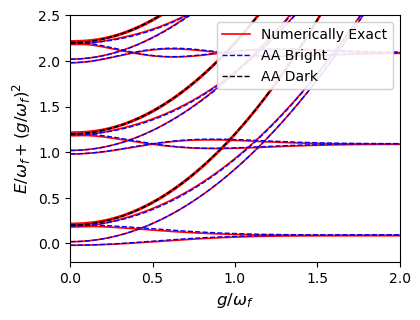

In [26]:
##Spectrum plot
plt.clf()
fig1, ax1 = plt.subplots(figsize=(4.25,3.2))
plt.ylim(-0.2, 2.5)
plt.xlim(0,2)
#plt.style.use('ggplot')
ax1.grid(False)
brightlines = 50
darklines = 3
# miffy code miffy code
for n in range(len(fulldiag_spec)):
    MQRM_line, = ax1.plot(geff_list,fulldiag_spec[n], color = 'red', label='Numerically Exact', linestyle = '-',linewidth=1.2)
for n in range(len(brightAAspec)):
    AA_bright_lines, = ax1.plot(geff_list,brightAAspec[n],color = 'blue', label = 'AA Bright',linestyle = '--', linewidth = 1)
for n in range(len(darkAAspec)):
    AA_dark_lines, = ax1.plot(geff_list,darkAAspec[n],color = 'black',label = 'AA Dark',linestyle = '--',linewidth = 1)
    
#ax1.set_title(r'$\sigma_1$ E plot with $\omega_a/\omega_f=$' + str(wa/wc) + r', $\sigma_2/\sigma_1 \approx $' + str(round(sigma[1]/sigma[0],2)) + r', and $\varepsilon_1,\varepsilon_2 = $' + str(ep1) + ',' + str(ep2))
ax1.set_ylabel(r'$E/\omega_f+\left(g/\omega_f\right)^2$',fontsize='large')
ax1.set_xlabel(r'$g/\omega_f$',fontsize='large')
ax1.legend(handles=[MQRM_line,AA_bright_lines,AA_dark_lines],loc = 'upper right', framealpha=0.9)
plt.savefig('AAverificationSPEC.png',bbox_inches="tight",dpi=1000)

In [27]:
#QFI comparisons
g1=0.8
g2=5

C = 0.265622
minT, maxT, num = 1e-6,1e4,100
Tlist = np.geomspace(minT,maxT,num)
twolspeaks = [C/T**2 for T in Tlist]

exact_trunc1 = 200
exact_trunc2 = 200
exact_cutoff1 = 1000
exact_cutoff2 = 1000

System1 = t.DoubleMultilevel(exact_trunc1, Dg, De, Cmat, g1, delta_g, delta_e, wf, wa)
H = System1.hamiltonian()
eigvals, _ = H.eigenstates()
Eexact1 = np.sort(eigvals)[0:exact_cutoff1]
trunc1 = int(exact_cutoff1/(Dg+De))

System2 = t.DoubleMultilevel(exact_trunc2, Dg, De, Cmat, g2, delta_g, delta_e, wf, wa)
H = System2.hamiltonian()
eigvals, _ = H.eigenstates()
Eexact2 = np.sort(eigvals)[0:exact_cutoff2]
trunc2 = int(exact_cutoff2/(Dg+De))

#####QFI
QFIexact1,_ = generate_qfi_list_fromE(Eexact1, minT, maxT, num)
QFIexact2,_ = generate_qfi_list_fromE(Eexact2, minT, maxT, num)
o=5
QFItheorallg1 = generate_qfi_list_theor3(wf, wa, Xq, Tlist, Dg, De, Dmin, Dplu, Dk, gprefactor=g1,Ocutoff = o)
QFItheorallg2 = generate_qfi_list_theor3_fast(wf, wa, Xq, Tlist, Dg, De, Dmin, Dplu, Dk, gprefactor=g2,Ocutoff = o)

#QFItheorlowg1 = generate_qfi_list_theor2(wf, wa, Xq, Tlist, Dg, De, Dmin, Dplu, Dk, gprefactor=g1)
#FItheorlowg2 = generate_qfi_list_theor2(wf, wa, Xq, Tlist, Dg, De, Dmin, Dplu, Dk, gprefactor=g2)

In [28]:
def ideal_therm_qfi(Elevels,gap,Tlist):
    Tlist = [mpf(T) for T in Tlist]
    Elevels = mpf(Elevels)
    gap = mpf(gap)
    qfi = [float(mpmath.power(1/T,4) * mpmath.exp(1/T*gap) * mpmath.power(gap, 2) * (Elevels-mpf(1)) * mpmath.power(Elevels-mpf(1)+mpmath.exp(1/T*gap),-2)) for T in Tlist]
    return qfi

In [29]:
Elevels=2
gap1 = Eexact1[1]-Eexact1[0]
gap2 = Eexact2[1]-Eexact2[0]
tls1 = ideal_therm_qfi(Elevels,gap1,Tlist)
tls2 = ideal_therm_qfi(Elevels,gap2,Tlist)

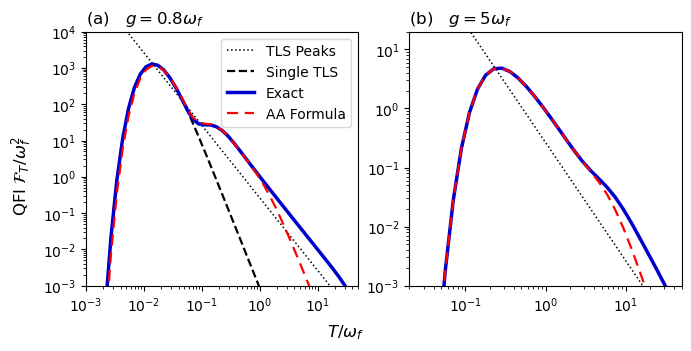

In [30]:
##plottingQFIcomparisons
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(6.8,3.4),sharex=False, sharey=False, constrained_layout=True)

dots = 'black'


fat = 'mediumblue'
solid = 'red' # mixes with fat
dash  = 'green' # mixes with solid

axs[0].loglog(Tlist, twolspeaks, label='TLS Peaks', lw=1.1, ls=':', color=dots)
axs[0].semilogx(Tlist,tls1,label=r'Single TLS',lw=1.6,ls='--',color='black')
axs[0].semilogx(Tlist,QFIexact1,label='Exact',lw=2.5,ls='-',color=fat)
axs[0].semilogx(Tlist,QFItheorallg1,label=r'AA Formula',lw=1.6,ls=(0, (5, 3)),color=solid)
#axs[0].semilogx(Tlist,QFItheorlowg1,label=r'$n=0$ AA',lw=1.2,ls='--',color='green')


axs[0].set_title(r'(a)   $g=0.8\omega_f$',fontsize='large',loc='left')

axs[1].loglog(Tlist, twolspeaks, lw=1.1, ls=':', color=dots)

axs[1].semilogx(Tlist,QFIexact2,lw=2.5,ls='-',color=fat)
axs[1].semilogx(Tlist,QFItheorallg2,lw=1.6,ls=(0, (5, 3)),color=solid)
#axs[1].loglog(Tlist,QFItheorlowg2,lw=1.5,ls='--',color=dash)

axs[1].set_title(r'(b)   $g=5\omega_f$',fontsize='large',loc='left')

axs[0].set_xlim([1e-3,5e1])
axs[0].set_ylim([1e-3,1e4])
axs[0].set_xscale("log")

axs[1].set_xlim([2e-2,5e1])
axs[1].set_ylim([1e-3,2e1])
axs[1].set_xscale("log")

fig.supxlabel(r'$T/\omega_f$',fontsize='large')
fig.supylabel(r'QFI $\mathcal{F}_{T}/\omega_f^2$',fontsize='large')

handles, labels = axs[0].get_legend_handles_labels()
axs[0].legend(handles, labels, loc='best')
plt.savefig('AAverificationQFI.png',bbox_inches="tight",dpi=1000)